# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [34]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [35]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [36]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [37]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [38]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [39]:
phase3_features = get_phase3_features()

In [40]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [41]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [42]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4064
      Test MAE: 5.03 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5394
      Test MAE: 11.69 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4699
      Test MAE: 18.30 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  1.0000
      Test MAE: 0.00 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9533
      Test MAE: 16.04 HP

All 5 models trained successfully!


In [43]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
     speed_fly_deviation     2.343288
condition_immunity_count     2.265209
  speed_ground_deviation     2.229699
     total_ability_count    -1.651863
      inflicts_petrified    -1.524028
      inflicts_paralyzed    -1.115979
        has_spellcasting    -1.011155
        inflicts_blinded    -0.811152
  save_proficiency_count     0.786843
             speed_climb    -0.777283

CR2 Top Features by Coefficient:
                feature  coefficient
 save_proficiency_count     5.479282
skill_proficiency_count    -4.310377
             speed_swim     3.935137
    vulnerability_count     3.653208
   movement_types_count    -3.238387
       inflicts_charmed    -3.136612
            speed_climb    -2.655645
 size_ordinal_deviation     2.622343
    inflicts_frightened    -2.480479
     inflicts_petrified    -2.471792

CR3 Top Features by Coefficient:
                 feature  coefficient
  save_proficiency_count    11.9838

## Investigate Specific Creatures

In [44]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# investigate_creature('Adult Red Dragon', df, contributions_df)
# investigate_creature('Tarrasque', df, contributions_df)
investigate_creature('Cult Fanatic', df, contributions_df)
# Issue - what's in parquet vs. what was in csv

  CULT FANATIC (CR 2.0)

Actual HP:              33
Predicted HP:           31
Error:                  -2  (  -7.0%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 2.0):                                54

PHASE 1.5: RESISTANCES & IMMUNITIES
  No resistances or immunities
  HP after Phase 1.5:                                    54

PHASE 2: COMBAT STATS
  Attack Bonus Contribution                            3
  DPR Contribution                                     0
  Save DC Contribution                                10
  -----------------------------------------------------
  Phase 2 Total:                                         14
  HP after Phase 2:                                      68

PHASE 3: INDIVIDUAL FEATURES
  Feature: has_legendary_resistance_scaled     value:    0.0  hp impact:     -0
  Feature: has_magic_resistance_scaled         value:    0.0  hp impact:     -0
  Feature: has_regeneration_scale

In [45]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [46]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
  Cockatrice 0.500         27     27.000015 -0.000015
     Cultist 0.125          9      9.000100 -0.000100
    Commoner 0.000          4      3.937506  0.062494
      Stirge 0.125          2      1.907068  0.092932
    Axe Beak 0.250         19     18.856469  0.143531
        Wolf 0.250         11     10.856153  0.143847
Magma Mephit 0.500         22     21.844324  0.155676
       Camel 0.125         15     15.356469 -0.356469
        Pony 0.125         11     11.365720 -0.365720
        Worg 0.500         26     25.601685  0.398315

CR < 1 - Worst 10 Predictions:
           Name   CR  Actual_HP  Predicted_HP      Error
     Black Bear 0.50         19     29.834249 -10.834249
        Octopus 0.00          3     -8.212143  11.212143
     Giant Wasp 0.50         13     25.098309 -12.098309
      Crocodile 0.50         19     31.309277 -12.309277
         Dretch 0.25         18      5.336162  12.663838
 

In [47]:
analysis_dfs['cr1']['has_flying']

99    1
39    0
28    0
33    1
57    0
     ..
53    0
85    0
18    0
67    1
88    0
Name: has_flying, Length: 113, dtype: int64


📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


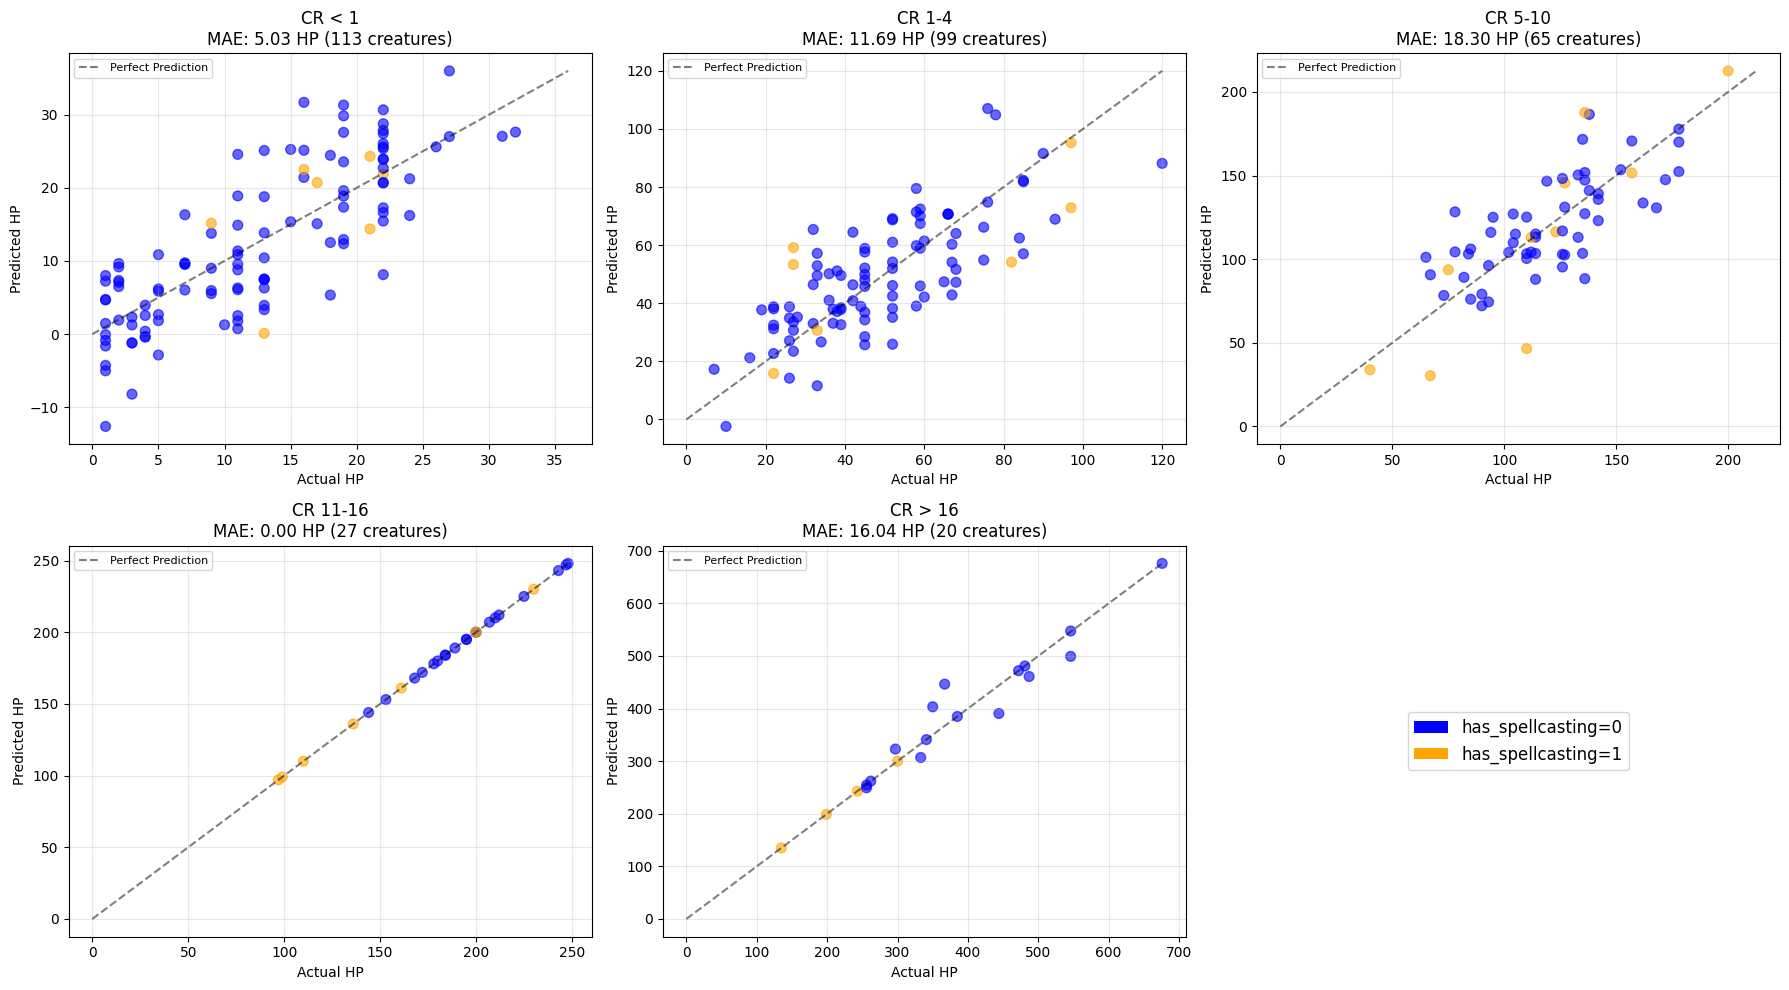

In [50]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_spellcasting')


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


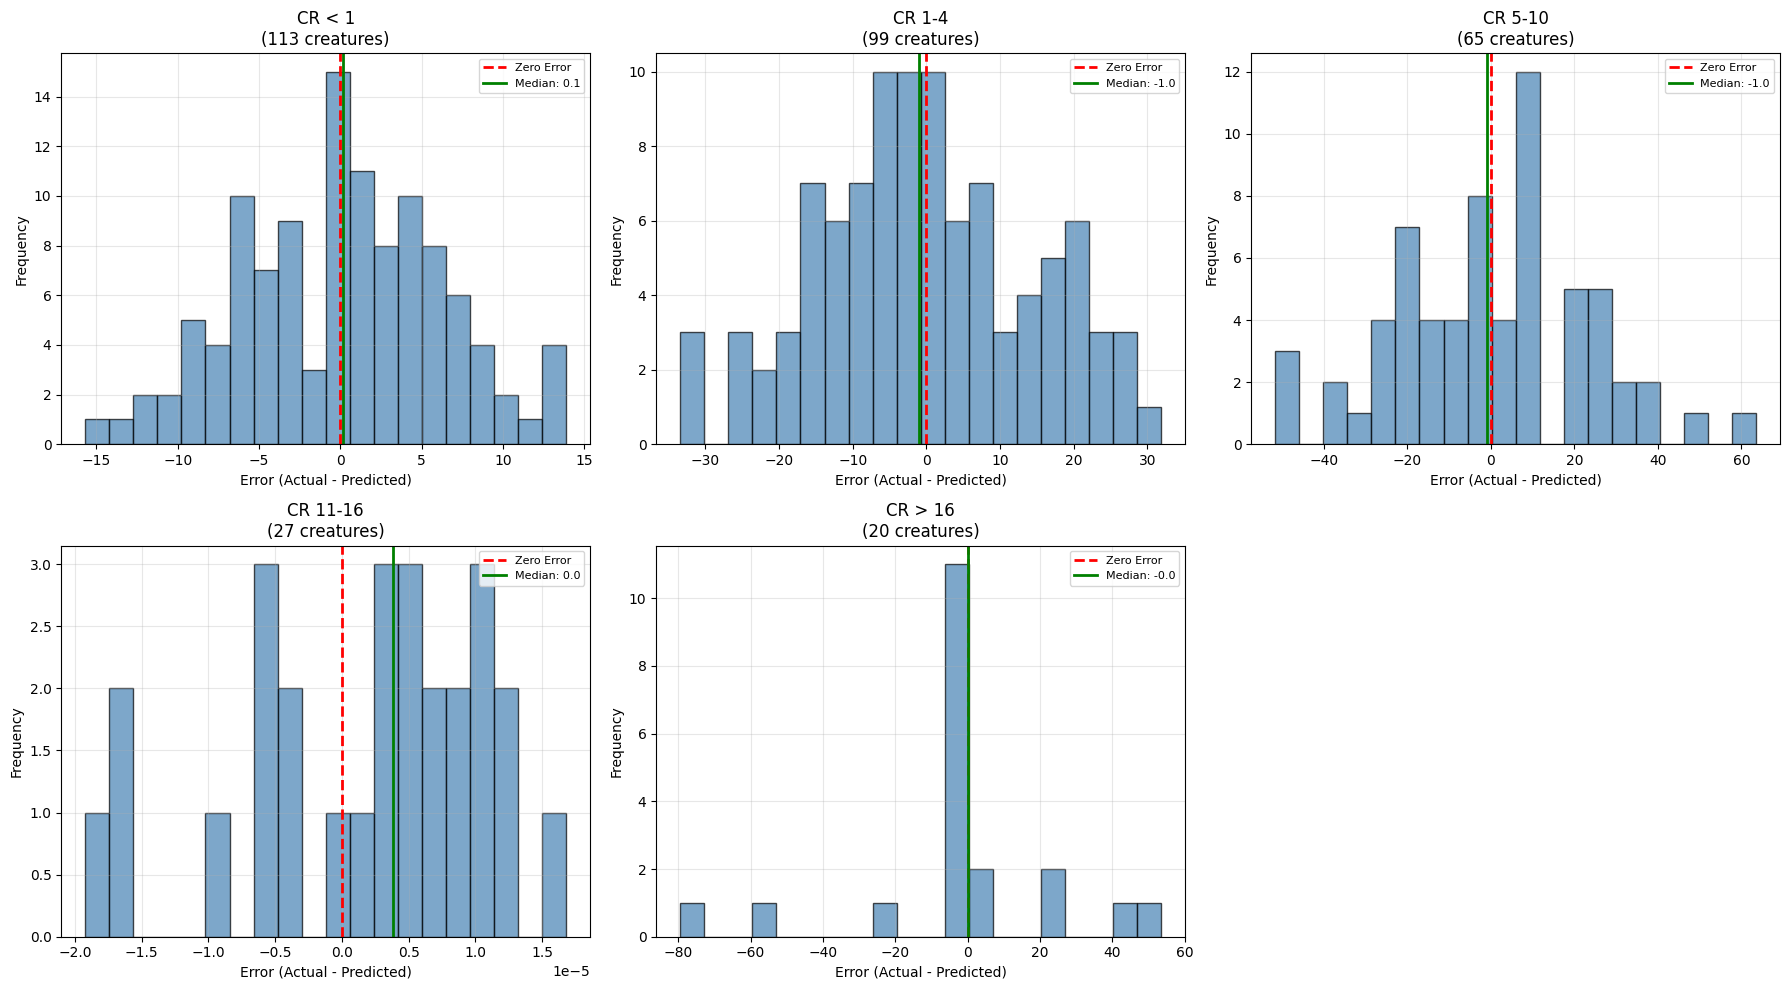

In [49]:
plot_error_hist(analysis_dfs)